In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import healpy as hp
import json
import pickle

from fpp.utils.validation import roc_finite_sample_band
from fpp.utils.posterior import multi_corner, dnds_posterior

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.image import imread
mpl.rc_file("./matplotlibrc")

# Common definitions

In [2]:
production_dir = "../outputs/production"
fits_dir = production_dir + '/fits'
truths_dir = production_dir + '/../truths'

label_latex_d = {
    'S_pib': r'$S_\mathrm{pib}$',
    'S_ics': r'$S_\mathrm{ics}$',
    'S_iso': r'$S_\mathrm{iso}$',
    'S_bub': r'$S_\mathrm{bub}$',
    'S_gce': r'$S_\mathrm{gce}$',
    'S_nfw': r'$S_\mathrm{nfw}$',
    'Sps_dsk': r'$S_\mathrm{dsk}^\mathrm{ps}$',
    'Sps_gce': r'$S_\mathrm{gce}^\mathrm{ps}$',
    'Sps_nfw': r'$S_\mathrm{nfw}^\mathrm{ps}$',
    'A_dsk': r'$A_\mathrm{dsk}^\mathrm{ps}$',
    'A_nfw': r'$A_\mathrm{nfw}^\mathrm{ps}$',
    'f_bulge_poiss': r'$f_\mathrm{bulge}^\mathrm{pois}$',
    'f_bulge_ps':    r'$f_\mathrm{bulge}^\mathrm{ps}$',
    'gamma_poiss': r'$\gamma^\mathrm{pois}$',
    'gamma_ps':    r'$\gamma^\mathrm{ps}$',
    'C': r'$C$',
    'zs': r'$z_s$',
    'sb_nfw': r'$S_b^\mathrm{nfw}$',
    'sb_dsk': r'$S_b^\mathrm{dsk}$',
}
fit_type_d = {
    'hmc': r'$\textbf{HMC}$',
    'svi': r'$\textbf{SVI}$',
    'nptfit': r'$\textbf{NPTFit}$',
    'oaf0': r'$\textbf{O}$+$\textbf{A}$+$\textbf{F}$',
    'oaf1': None,
    'oaf2': None,
    'o0': r'$\textbf{O}$',
    'o1': None,
    'o2': None
}
colors_dict = {
    'hmc': 'gray',
    'svi': 'C0',
    'nptfit': 'C1',
    'oaf0': mpl.colormaps['binary'](0.8),
    'oaf1': mpl.colormaps['binary'](0.5),
    'o0': mpl.colormaps['Blues'](0.8),
    'o1': mpl.colormaps['Blues'](0.5),
}

# I. Not calibration

## I-1.1 fermi

In [ ]:
plot_name = 'fermi'

labels = ['S_pib', 'S_ics', 'S_gce', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs']
fn_dict = {
    'hmc' : f'{fits_dir}/fermi/hmc-seed42.p',
    'svi' : f'{fits_dir}/fermi/svi-seed42.p',
}

s_in = {}
for key, fn in fn_dict.items():
    s = pickle.load(open(fn, 'rb'))
    s_in[key] = {k: s[k] for k in labels}

multi_corner(
    s_in, labels,
    colors_dict=colors_dict, legend_dict=fit_type_d, legend_loc=(0.15, 0.94),
    labels=[label_latex_d[k] for k in labels],
    label_kwargs={"fontsize": 30},
    save_fn=f'../outputs/production/plots/{plot_name}-post.png',
)

## I-1.2 fermi-dnds

In [4]:
def dnds_post_data():
    labels_func = lambda k: [f'Sps_{k}', f'n1_{k}', f'n2_{k}', f'n3_{k}', f'sb1_{k}', f'lambdas_{k}']
    samples_hmc = pickle.load(open(f'{fits_dir}/fermi/hmc-seed42.p', 'rb'))
    samples_svi = pickle.load(open(f'{fits_dir}/fermi/svi-seed42.p', 'rb'))
    dnds_d = {}
    dnds_d['gce-hmc'] = dnds_posterior(samples=samples_hmc, theta_keys=labels_func('gce'), plot=False)
    dnds_d['gce-svi'] = dnds_posterior(samples=samples_svi, theta_keys=labels_func('gce'), plot=False)
    dnds_d['dsk-hmc'] = dnds_posterior(samples=samples_hmc, theta_keys=labels_func('dsk'), plot=False)
    dnds_d['dsk-svi'] = dnds_posterior(samples=samples_svi, theta_keys=labels_func('dsk'), plot=False)
    return dnds_d

def plot_dnds_post(ax, dnds_d, k, xlabel=False, ylabel=False, title='', style='new'):
    s, dnds_med, dnds_68, dnds_95 = dnds_d[f'{k}-hmc']
    if style == 'new':
        color = 'gray'
        ax.plot(s, dnds_med, color=color, label=r'$\textbf{HMC}$')
        ax.plot(s, dnds_68[0], color=color, lw=1.5, ls='--', alpha=0.7)
        ax.plot(s, dnds_68[1], color=color, lw=1.5, ls='--', alpha=0.7)
        ax.plot(s, dnds_95[0], color=color, lw=1.5, ls='--', alpha=0.5)
        ax.plot(s, dnds_95[1], color=color, lw=1.5, ls='--', alpha=0.5)
        ax.fill_between(s, dnds_68[0], dnds_68[1], alpha=0.2, fc='k', ec='none')
        # ax.fill_between(s, dnds_95[0], dnds_95[1], alpha=0.2, fc='k', ec='none')
    else:
        ax.plot(s, dnds_med, color='k', label=r'$\textbf{HMC}$')
        ax.fill_between(s, dnds_68[0], dnds_68[1], alpha=0.5, fc='C0', ec='none')
        ax.fill_between(s, dnds_95[0], dnds_95[1], alpha=0.3, fc='C0', ec='none')
    s, dnds_med, dnds_68, dnds_95 = dnds_d[f'{k}-svi']
    if style == 'new':
        color = 'C0'
        ax.plot(s, dnds_med, color=color, label=r'$\textbf{SVI}$')
        ax.plot(s, dnds_68[0], color=color, lw=1.5, ls='--', alpha=0.7)
        ax.plot(s, dnds_68[1], color=color, lw=1.5, ls='--', alpha=0.7)
        ax.plot(s, dnds_95[0], color=color, lw=1.5, ls='--', alpha=0.5)
        ax.plot(s, dnds_95[1], color=color, lw=1.5, ls='--', alpha=0.5)
        ax.fill_between(s, dnds_68[0], dnds_68[1], alpha=0.2, fc='C0', ec='none')
        # ax.fill_between(s, dnds_95[0], dnds_95[1], alpha=0.2, fc='C0', ec='C0', ls='-')
    else:
        ax.plot(s, dnds_med, color='k', ls='--', label=r'$\textbf{SVI}$')
        ax.fill_between(s, dnds_68[0], dnds_68[1], alpha=1.0, fc='none', ec='k', ls='--')
        ax.fill_between(s, dnds_95[0], dnds_95[1], alpha=0.6, fc='none', ec='k', ls='--')
    ax.set(xlim=(1, 50), ylim=(1e-7, 1))
    ax.set(xscale='log', yscale='log')
    if xlabel:
        ax.set(xlabel='$S$ [counts]')
    if ylabel:
        ax.set(ylabel=r'$\mathrm{d}N/\mathrm{d}S$ [counts$^{-1}$]')
    ax.set(title=title)
    ax.legend(frameon=False)

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

dnds_d = dnds_post_data()

plot_dnds_post(axs[0], dnds_d, 'gce', title=r'$\textbf{GCE Point Source}$', xlabel=False, ylabel=True)
plot_dnds_post(axs[1], dnds_d, 'dsk', title=r'$\textbf{Disk Point Source}$', xlabel=True, ylabel=True)

fig.tight_layout()
fig.savefig(f'../outputs/production/plots/fermi-dnds-post.png', dpi=300, bbox_inches='tight')

## I-1.3 fermi-combined

In [ ]:
from matplotlib.image import imread

img = imread('../outputs/production/plots/fermi-post.png')
dpi = 300
height, width = img.shape[:2]

fig = plt.figure(figsize=(width / dpi, height / dpi), dpi=dpi)
ax = fig.add_axes([0, 0, 1, 1])

ax.imshow(img)
ax.axis('off')
ax.set_xlim(0, width)
ax.set_ylim(height, 0)

img2 = imread('../outputs/production/plots/fermi-dnds-post.png')
h2, w2 = img2.shape[:2]
ax2 = fig.add_axes([0.58, 0.48, 1.1 * w2 / width, 1.1 * h2 / height])

ax2.imshow(img2)
ax2.axis('off')
ax2.set_xlim(0, w2)
ax2.set_ylim(h2, 0)

fig.savefig('../outputs/production/plots/fermi-post-combined.png', dpi=dpi, pad_inches=0)
# plt.close(fig)

## I-1.4 fermi other variables

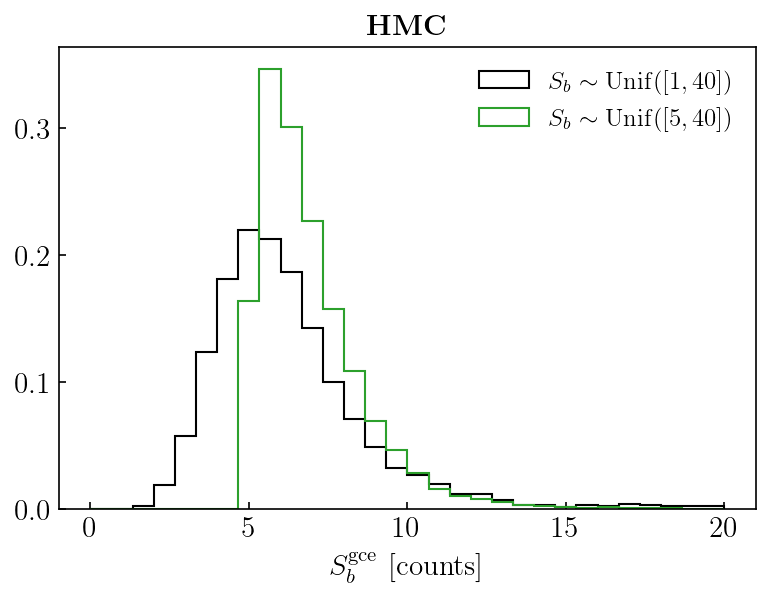

In [ ]:
s0 = pickle.load(open(f'{fits_dir}/fermi/hmc-Sb1-seed42.p', 'rb'))
s1 = pickle.load(open(f'{fits_dir}/fermi/hmc-seed42.p', 'rb'))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(s0['sb1_gce'], histtype='step', label=r'$S_b\sim\mathrm{Unif}([1,40])$', color='k', bins=np.linspace(0, 20, 31), density=True)
ax.hist(s1['sb1_gce'], histtype='step', label=r'$S_b\sim\mathrm{Unif}([5,40])$', color='C1', bins=np.linspace(0, 20, 31), density=True)
ax.set(xlabel=r'$S_b^\mathrm{gce}$ [counts]', title=r'$\textbf{HMC}$')
ax.legend(frameon=False);

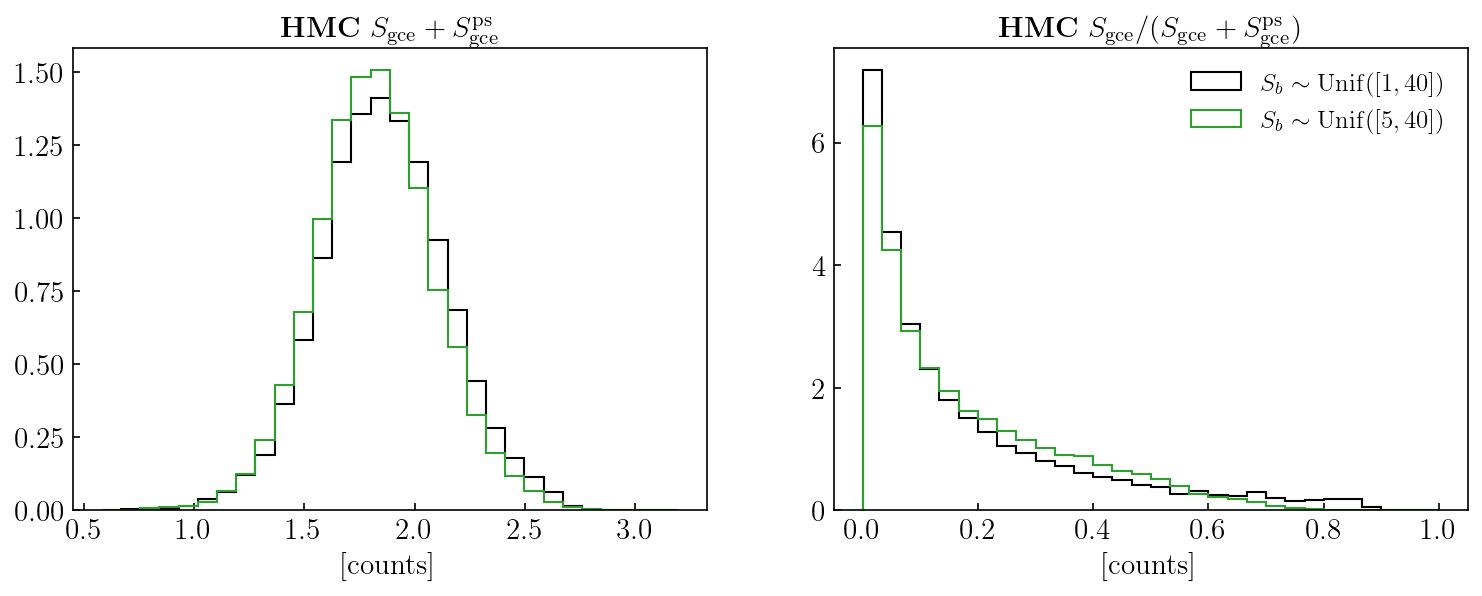

In [16]:
total0 = s0['S_gce'] + s0['Sps_gce']
total1 = s1['S_gce'] + s1['Sps_gce']
f0 = s0['S_gce'] / total0
f1 = s1['S_gce'] / total1

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

vmin = np.min([total0, total1])
vmax = np.max([total0, total1])
ax = axs[0]
ax.hist(total0, histtype='step', label=r'$S_b\sim\mathrm{Unif}([1,40])$', color='k', bins=np.linspace(vmin, vmax, 31), density=True)
ax.hist(total1, histtype='step', label=r'$S_b\sim\mathrm{Unif}([5,40])$', color='C1', bins=np.linspace(vmin, vmax, 31), density=True)
ax.set(xlabel='[counts]', title=r'$\textbf{HMC}$ $S_\mathrm{gce}+S^\mathrm{ps}_\mathrm{gce}$')

ax = axs[1]
ax.hist(f0, histtype='step', label=r'$S_b\sim\mathrm{Unif}([1,40])$', color='k', bins=np.linspace(0, 1, 31), density=True)
ax.hist(f1, histtype='step', label=r'$S_b\sim\mathrm{Unif}([5,40])$', color='C1', bins=np.linspace(0, 1, 31), density=True)
ax.set(xlabel='[counts]', title=r'$\textbf{HMC}$ $S_\mathrm{gce}/(S_\mathrm{gce}+S^\mathrm{ps}_\mathrm{gce})$')
ax.legend(frameon=False);

## I-1.5 fermi-full

In [4]:
from fpp.models.np_model import NPModel

In [5]:
m = NPModel()

No data provided. Using Fermi data.


In [6]:
s = pickle.load(open(f'{fits_dir}/fermi/hmc-seed42.p', 'rb'))
s = m.expand_samples(s)
pickle.dump(s, open(f'{fits_dir}/fermi/hmc-seed42-expanded.p', 'wb'))
s.keys()

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'C', 'S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_poiss_mcdermott2022', 'theta_poiss_mcdermott2022_bbp', 'theta_poiss_mcdermott2022_x', 'theta_poiss_macias2019', 'theta_poiss_coleman2019', 'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019', 'theta_ics_ModelO', 'theta_ics_ModelA', 'theta_ics_ModelF', 'theta_pib_ModelO', 'theta_pib_ModelA', 'theta_pib_ModelF', 'zs'])

In [24]:
label_latex_d_extra = {
    'n1_dsk': r'$n_1^\mathrm{dsk}$',
    'n2_dsk': r'$n_2^\mathrm{dsk}$',
    'n3_dsk': r'$n_3^\mathrm{dsk}$',
    'sb1_dsk': r'$S_{b,1}^\mathrm{dsk}$',
    'lambdas_dsk': r'$\lambda_s^\mathrm{dsk}$',
    'n1_gce': r'$n_1^\mathrm{gce}$',
    'n2_gce': r'$n_2^\mathrm{gce}$',
    'n3_gce': r'$n_3^\mathrm{gce}$',
    'sb1_gce': r'$S_{b,1}^\mathrm{gce}$',
    'lambdas_gce': r'$\lambda_s^\mathrm{gce}$',
    'theta_poiss_mcdermott2022': r'$\alpha_\mathrm{BB}^\mathrm{pois}$',
    'theta_poiss_mcdermott2022_bbp': r'$\alpha_\mathrm{BBP}^\mathrm{pois}$',
    'theta_poiss_mcdermott2022_x': r'$\alpha_\mathrm{X}^\mathrm{pois}$',
    'theta_poiss_macias2019': r'$\alpha_\mathrm{Mac19}^\mathrm{pois}$',
    'theta_poiss_coleman2019': r'$\alpha_\mathrm{Col19}^\mathrm{pois}$',
    'theta_ps_mcdermott2022': r'$\alpha_\mathrm{BB}^\mathrm{ps}$',
    'theta_ps_mcdermott2022_bbp': r'$\alpha_\mathrm{BBP}^\mathrm{ps}$',
    'theta_ps_mcdermott2022_x': r'$\alpha_\mathrm{X}^\mathrm{ps}$',
    'theta_ps_macias2019': r'$\alpha_\mathrm{Mac19}^\mathrm{ps}$',
    'theta_ps_coleman2019': r'$\alpha_\mathrm{Col19}^\mathrm{ps}$',
    'theta_pib_ModelO': r'$\alpha_\mathrm{pib}^\mathrm{O}$',
    'theta_pib_ModelA': r'$\alpha_\mathrm{pib}^\mathrm{A}$',
    'theta_pib_ModelF': r'$\alpha_\mathrm{pib}^\mathrm{F}$',
    'theta_ics_ModelO': r'$\alpha_\mathrm{ics}^\mathrm{O}$',
    'theta_ics_ModelA': r'$\alpha_\mathrm{ics}^\mathrm{A}$',
    'theta_ics_ModelF': r'$\alpha_\mathrm{ics}^\mathrm{F}$',
    'Alm_0': r'$A_{\ell m,0}$',
    'Alm_1': r'$A_{\ell m,1}$',
    'Alm_2': r'$A_{\ell m,2}$',
    'Alm_3': r'$A_{\ell m,3}$',
    'Alm_4': r'$A_{\ell m,4}$',
    'f_bulge_poiss*S_gce': r'$f_\mathrm{bulge}^\mathrm{pois}S_\mathrm{gce}$',
    'f_bulge_ps*Sps_gce': r'$f_\mathrm{bulge}^\mathrm{ps}S_\mathrm{gce}^\mathrm{ps}$',
}
label_latex_d.update(label_latex_d_extra)

In [ ]:
plot_name = 'fermi-full'

unused_labels = []

labels = [
    'S_pib', 'S_ics', 'S_bub', 'S_iso', 'S_gce', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs',
    'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk',
    'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce',
    'theta_poiss_mcdermott2022', 'theta_poiss_mcdermott2022_bbp', 'theta_poiss_mcdermott2022_x', 'theta_poiss_macias2019', 'theta_poiss_coleman2019',
    'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019',
    'theta_pib_ModelO', 'theta_pib_ModelA', 'theta_pib_ModelF',
    'theta_ics_ModelO', 'theta_ics_ModelA', 'theta_ics_ModelF',
    'Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4',
]
fn_dict = {
    'hmc' : f'{fits_dir}/fermi/hmc-seed42.p',
    'svi' : f'{fits_dir}/fermi/svi-seed42.p',
}

s_in = {}
for key, fn in fn_dict.items():
    s = pickle.load(open(fn, 'rb'))
    s = m.expand_samples(s)
    s_in[key] = {k: s[k] for k in labels}

multi_corner(
    s_in, labels,
    colors_dict=colors_dict, legend_dict=fit_type_d, legend_loc=(0.15, 0.94),
    labels=[(label_latex_d[k] if k in label_latex_d else k) for k in labels],
    label_kwargs={"fontsize": 30},
    save_fn=f'../outputs/production/plots/{plot_name}-post.pdf',
)

## I-1.6 fermi partial

In [12]:
samples_d = {
    'hmc': pickle.load(open(f'{fits_dir}/fermi/hmc-seed42-expanded.p', 'rb')),
    'svi': pickle.load(open(f'{fits_dir}/fermi/svi-seed42.p', 'rb')),
}

In [ ]:
# plot_name = 'fermipib'
# labels = ['S_pib', 'theta_pib_ModelO', 'theta_pib_ModelA', 'theta_pib_ModelF']
# plot_name = 'fermiics'
# labels = ['S_ics', 'theta_ics_ModelO', 'theta_ics_ModelA', 'theta_ics_ModelF']
# plot_name = 'fermipoisbulge'
# labels = ['f_bulge_poiss*S_gce', 'theta_poiss_mcdermott2022', 'theta_poiss_mcdermott2022_bbp', 'theta_poiss_mcdermott2022_x', 'theta_poiss_macias2019', 'theta_poiss_coleman2019']
plot_name = 'fermipsbulge'
labels = ['f_bulge_ps*Sps_gce', 'theta_ps_mcdermott2022', 'theta_ps_mcdermott2022_bbp', 'theta_ps_mcdermott2022_x', 'theta_ps_macias2019', 'theta_ps_coleman2019']

s_in = {}
for key, s in samples_d.items():
    s['f_bulge_poiss*S_gce'] = s['f_bulge_poiss'] * s['S_gce']
    s['f_bulge_ps*Sps_gce'] = s['f_bulge_ps'] * s['Sps_gce']
    s_in[key] = {k: s[k] for k in labels}

multi_corner(
    s_in, labels,
    colors_dict=colors_dict, legend_dict=fit_type_d if plot_name in ['fermipib', 'fermipoisbulge'] else None,
    legend_loc=(0.35, 0.85) if plot_name == 'fermipib' else (0.25, 0.9),
    labels=[label_latex_d[k] for k in labels],
    label_kwargs={"fontsize": 30},
    save_fn=f'../outputs/production/plots/{plot_name}-post.png',
)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

dpi = 300
fn_fmt_str = '../outputs/production/plots/fermi%s-post.png'
# tag_s = ['pib', 'ics']
# save_fn = '../outputs/production/plots/fermipibics-post.png'
tag_s = ['poisbulge', 'psbulge']
save_fn = '../outputs/production/plots/fermibulge-post.png'
img_left = imread(fn_fmt_str % tag_s[0])
img_right = imread(fn_fmt_str % tag_s[1])

h_l, w_l = img_left.shape[:2]
h_r, w_r = img_right.shape[:2]

total_w = w_l + w_r
total_h = max(h_l, h_r)

fig = plt.figure(figsize=(total_w / dpi, total_h / dpi), dpi=dpi)

ax1 = fig.add_axes([0, 0, w_l / total_w, h_l / total_h])
ax1.imshow(img_left)
ax1.axis('off')

ax2 = fig.add_axes([w_l / total_w, 0, w_r / total_w, h_r / total_h])
ax2.imshow(img_right)
ax2.axis('off')

fig.savefig(save_fn, dpi=dpi, facecolor='white')
# plt.close(fig)

## I-2. cmp: NPTFit vs. HMC & SVI

In [ ]:
# post-processing
import jax
import jax.numpy as jnp
from fpp.models.scd import dnds_1b
from tqdm import tqdm

s_arr = np.logspace(-1, 2, 1000)

@jax.vmap
def get_Sps(A, n1, n2, sb):
    dnds = dnds_1b(s_arr, jnp.array([A, n1, n2, sb]))
    return jnp.trapz(s_arr * dnds, s_arr)

for name in ['hmc', 'svi', 'nptfit']:
    s = pickle.load(open(f'{fits_dir}/cmp/{name}_samples.p', 'rb'))
    for k in ['nfw', 'dsk']:
        s[f'Sps_{k}'] = get_Sps(s[f'A_{k}'], s[f'n1_{k}'], s[f'n2_{k}'], s[f'sb_{k}'])
    pickle.dump(s, open(f'{fits_dir}/cmp/{name}_samples.p', 'wb'))

In [ ]:
plot_name = 'cmp'

labels = ['S_pib', 'S_ics', 'S_nfw', 'Sps_nfw', 'Sps_dsk', 'sb_nfw', 'sb_dsk']
fn_dict = {
    'hmc' : f'{fits_dir}/cmp/hmc_samples.p',
    'svi' : f'{fits_dir}/cmp/svi_samples.p',
    'nptfit' : f'{fits_dir}/cmp/nptfit_samples.p',
}
truth_dict = json.load(open(truths_dir + '/truth_dict_cmp.json', 'r'))

# legend_dict = {k : v + ('$\quad$ Trivial PSF' if deltapsf else '$\quad$ King PSF') for k, v in fit_type_d.items()}
legend_dict = fit_type_d
legend_loc = (0.23, 0.88)

#----------------------------------------
s_in = {}
for key, fn in fn_dict.items():
    s = pickle.load(open(fn, 'rb'))
    s_in[key] = {k: s[k] for k in labels}

multi_corner(
    s_in, labels, point_est={k: truth_dict[k] for k in labels} if truth_dict is not None else None,
    colors_dict=colors_dict, legend_dict=legend_dict, legend_loc=legend_loc,
    labels=[label_latex_d[k] for k in labels],
    label_kwargs={"fontsize": 30},
    save_fn=f'../outputs/production/plots/{plot_name}-post.png',
)

## I-3. OAF vs O

In [ ]:
plot_name = 'oafvso'

labels = ['S_bub', 'S_gce', 'Sps_gce', 'Sps_dsk', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps']
fn_dict = {
    'oaf0' : f'{fits_dir}/oaf/hmc-OAF-0.p',
    'oaf1' : f'{fits_dir}/oaf/hmc-OAF-1.p',
    'o0' : f'{fits_dir}/oaf/hmc-O-0.p',
    'o1' : f'{fits_dir}/oaf/hmc-O-1.p',
}
truth_dict = json.load(open(truths_dir + '/truth_dict_base230927new_p6v11.json', 'r'))

# legend_dict = {k : v + ('$\quad$ Trivial PSF' if deltapsf else '$\quad$ King PSF') for k, v in fit_type_d.items()}
legend_dict = fit_type_d
legend_loc = (0.21, 0.92)

#----------------------------------------
s_in = {}
for key, fn in fn_dict.items():
    s = pickle.load(open(fn, 'rb'))
    s_in[key] = {k: s[k] for k in labels}

multi_corner(
    s_in, labels, point_est={k: truth_dict[k] for k in labels} if truth_dict is not None else None,
    colors_dict=colors_dict, legend_dict=legend_dict, legend_loc=legend_loc,
    labels=[label_latex_d[k] for k in labels],
    save_fn=f'../outputs/production/plots/{plot_name}-post.png',
    label_kwargs={"fontsize": 30},
)

# II. Calibration

In [ ]:
def coverage(ax, test_name, fit_type, deltapsf=False, psf_names=True, show_legend=False, show_xlabel=True, show_ylabel=False):

    if deltapsf:
        deltapsf_str = '_deltapsf'
        psf = 'delta'
    else:
        deltapsf_str = ''
        psf = 'king'

    if test_name == 'pois':
        p_name = f'{fit_type}_Dpois_Mpois/p_nominal_actual_dict.json'
        z = json.load(open(f'{fits_dir}/{p_name}', 'r'))
    elif test_name == 'npnew':
        p_name = f'calibration-base23fix/{fit_type}_D23new{deltapsf_str}_Mbase23fix{deltapsf_str}/p_nominal_actual_dict.p'
        z = pickle.load(open(f'{fits_dir}/{p_name}', 'rb'))
    elif test_name == 'npold':
        p_name = f'calibration-base23fix/{fit_type}_Dbase23fix{deltapsf_str}_2_Mbase23fix{deltapsf_str}/p_nominal_actual_dict.p'
        z = pickle.load(open(f'{fits_dir}/{p_name}', 'rb'))
    elif test_name == 'npnew_updated':
        p_name = f'calibration/{fit_type}-new-{psf}/p_nominal_actual_dict.p'
        z = pickle.load(open(f'{fits_dir}/{p_name}', 'rb'))
    elif test_name == 'npold_updated':
        p_name = f'calibration/{fit_type}-old-{psf}/p_nominal_actual_dict.p'
        z = pickle.load(open(f'{fits_dir}/{p_name}', 'rb'))
    else:
        raise ValueError(f'Unknown test_name: {test_name}')

    if test_name == 'pois':
        labels = [
            'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
            'f_bulge_poiss', 'gamma_poiss',
        ]
    else:
        labels = [
            'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
            'Sps_dsk', 'Sps_gce',
            'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
        ]
    probs = [z[k] for k in labels]
    ls_s = ['-'] * 10 + [':'] * 10

    ax.fill_between([0,1], [0,1], color='lightgray')
    for prob, label, ls in zip(probs, labels, ls_s):
        ax.plot(prob[0], prob[1], label=label_latex_d[label], ls=ls)

    n_run = 30
    invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
    ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run}-sample 95\% containment')
    ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

    ax.set(aspect=1, xlim=(0, 1), ylim=(0, 1))
    if show_xlabel:
        ax.set(xlabel='Nominal coverage')
    if show_ylabel:
        ax.set(ylabel='Actual coverage')
    ax.text(0.05, 0.95, fit_type_d[fit_type], fontsize=16, va='top', ha='left', transform=ax.transAxes)
    if psf_names:
        if deltapsf:
            ax.text(0.05, 0.85, r'Trivial PSF', fontsize=16, va='top', ha='left', transform=ax.transAxes)
        else:
            ax.text(0.05, 0.85, r'King PSF', fontsize=16, va='top', ha='left', transform=ax.transAxes)

def posterior(save_fn, test_name, deltapsf=False, psf_names=True, i=0):

    if deltapsf:
        deltapsf_str = '_deltapsf'
        psf = 'delta'
    else:
        deltapsf_str = ''
        psf = 'king'

    if test_name == 'pois':
        labels = [
            'S_pib', 'S_ics', 'S_gce',
            'f_bulge_poiss', 'gamma_poiss'
        ]
        fn_dict = {
            'hmc' : f'{fits_dir}/hmc_Dpois_Mpois/i{i}_n10000_ns0.p',
            'svi' : f'{fits_dir}/svi_Dpois_Mpois/i{i}_n50000_ns10000.p',
        }
        truth_dict = json.load(open(truths_dir + '/truth_dict_pois230927.json', 'r'))
        legend_loc = (0.3, 0.9)

    elif test_name == 'npold':
        labels = [
            'S_pib', 'S_ics', 'S_gce',
            'Sps_dsk', 'Sps_gce',
            'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps',
        ]
        fn_dict = {
            'hmc' : f'{fits_dir}/calibration-base23fix/hmc_Dbase23fix{deltapsf_str}_2_Mbase23fix{deltapsf_str}/i{i}_n10000_ns0.p',
            'svi' : f'{fits_dir}/calibration-base23fix/svi_Dbase23fix{deltapsf_str}_2_Mbase23fix{deltapsf_str}/i{i}_n50000_ns10000.p',
        }
        truth_dict = json.load(open(truths_dir + '/truth_dict_base230927.json', 'r'))
        legend_loc = (0.2, 0.93)

    elif test_name == 'npnew':
        labels = [
            'S_pib', 'S_ics', 'S_gce',
            'Sps_dsk', 'Sps_gce',
            'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps'
        ]
        fn_dict = {
            'hmc' : f'{fits_dir}/calibration-base23fix/hmc_D23new{deltapsf_str}_Mbase23fix{deltapsf_str}/i{i}_n10000_ns0.p',
            'svi' : f'{fits_dir}/calibration-base23fix/svi_D23new{deltapsf_str}_Mbase23fix{deltapsf_str}/i{i}_n50000_ns10000.p',
        }
        truth_dict = json.load(open(truths_dir + '/truth_dict_base230927new.json', 'r'))
        legend_loc = (0.2, 0.93)

    elif test_name == 'npold_updated':
        labels = [
            'S_pib', 'S_ics', 'S_gce',
            'Sps_dsk', 'Sps_gce',
            'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps'
        ]
        fn_dict = {
            'hmc' : f'{fits_dir}/calibration/hmc-old-{psf}/{i}.p',
            'svi' : f'{fits_dir}/calibration/svi-old-{psf}/{i}.p',
        }
        truth_dict = json.load(open(truths_dir + '/truth_dict_base230927.json', 'r'))
        legend_loc = (0.2, 0.93)

    elif test_name == 'npnew_updated':
        labels = [
            'S_pib', 'S_ics', 'S_gce',
            'Sps_dsk', 'Sps_gce',
            'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps'
        ]
        fn_dict = {
            'hmc' : f'{fits_dir}/calibration/hmc-new-{psf}/{i}.p',
            'svi' : f'{fits_dir}/calibration/svi-new-{psf}/{i}.p',
        }
        truth_dict = json.load(open(truths_dir + '/truth_dict_base230927new.json', 'r'))
        legend_loc = (0.2, 0.93)

    s_in = {}
    
    for key, fn in fn_dict.items():
        s = pickle.load(open(fn, 'rb'))
        s_in[key] = {k: s[k] for k in labels}
    if truth_dict is not None:
        t_in = {k: truth_dict[k] for k in labels}
    else:
        t_in = None

    multi_corner(
        s_in, labels, point_est=t_in, colors_dict=colors_dict, legend_dict=legend_dict, save_fn=save_fn,
        labels=[label_latex_d[k] for k in labels], label_kwargs={"fontsize": 30}, legend_loc=legend_loc
    )

## II-1. poission coverage and post.

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

coverage(axs[0], test_name='pois', fit_type='hmc', show_ylabel=True, psf_names=False)
axs[0].legend(loc=(0.02, 1.02), frameon=False, ncol=4)
coverage(axs[1], test_name='pois', fit_type='svi', show_ylabel=False, psf_names=False)

fig.subplots_adjust(wspace=0.1)
fig.savefig('plots/pois-coverage.png', bbox_inches='tight', dpi=300)

In [ ]:
post_pois('plots/pois-post.png', psf_names=False)

In [ ]:
fn1 = './plots/pois-coverage.png'
fn2 = './plots/pois-post.png'
# Read the images
img1 = imread(fn1)
img2 = imread(fn2)

width_ratios = [2, 1.2]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': width_ratios})

axes[0].imshow(img1)
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('./plots/pois-combined.png', bbox_inches='tight', dpi=300)

## II-2. NP

In [ ]:
test_name = 'npold'

#===== coverage =====
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharey=True, sharex=True)

coverage(axs[0,0], test_name=test_name, deltapsf=True, fit_type='hmc', show_ylabel=True, show_xlabel=False)
axs[0,0].legend(loc=(0.02, 1.02), frameon=False, ncol=4)
coverage(axs[0,1], test_name=test_name, deltapsf=True, fit_type='svi', show_ylabel=False, show_xlabel=False)
coverage(axs[1,0], test_name=test_name, fit_type='hmc', show_ylabel=True, show_xlabel=True)
coverage(axs[1,1], test_name=test_name, fit_type='svi', show_ylabel=False, show_xlabel=True)

fig.subplots_adjust(wspace=0.1, hspace=0.1)
fig.savefig(f'../outputs/plots/{test_name}-coverage.png', bbox_inches='tight', dpi=300)

#===== posterior =====
posterior(f'../outputs/plots/{test_name}-post.png', test_name=test_name, deltapsf=False, i=1)

#===== combined =====
fn1 = f'../outputs/plots/{test_name}-coverage.png'
fn2 = f'../outputs/plots/{test_name}-post.png'

img1 = imread(fn1)
img2 = imread(fn2)

width_ratios = [1, 1.1]

fig, axes = plt.subplots(1, 2, figsize=(12, 9), gridspec_kw={'width_ratios': width_ratios})

axes[0].imshow(img1)
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].axis('off')

fig.subplots_adjust(wspace=0.)
plt.savefig(f'../outputs/plots/{test_name}-combined.png', bbox_inches='tight', dpi=300)

In [ ]:
test_name = 'npold_updated'
posterior(f'../outputs/plots/{test_name}-post-deltapsf.png', test_name=test_name, deltapsf=True, i=0)